In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
%matplotlib widget


In [26]:
from scipy.constants import c, k

In [27]:
distance = np.linspace(100, 4000, 100) * 1e3

In [28]:
center_freq = 436.5e6

In [29]:
def fspl_db(d, f):
    fspl = 20 * np.log10(d) + 20 * np.log10(f) - 147.55
    return fspl

In [30]:
fspl = fspl_db(distance, center_freq)

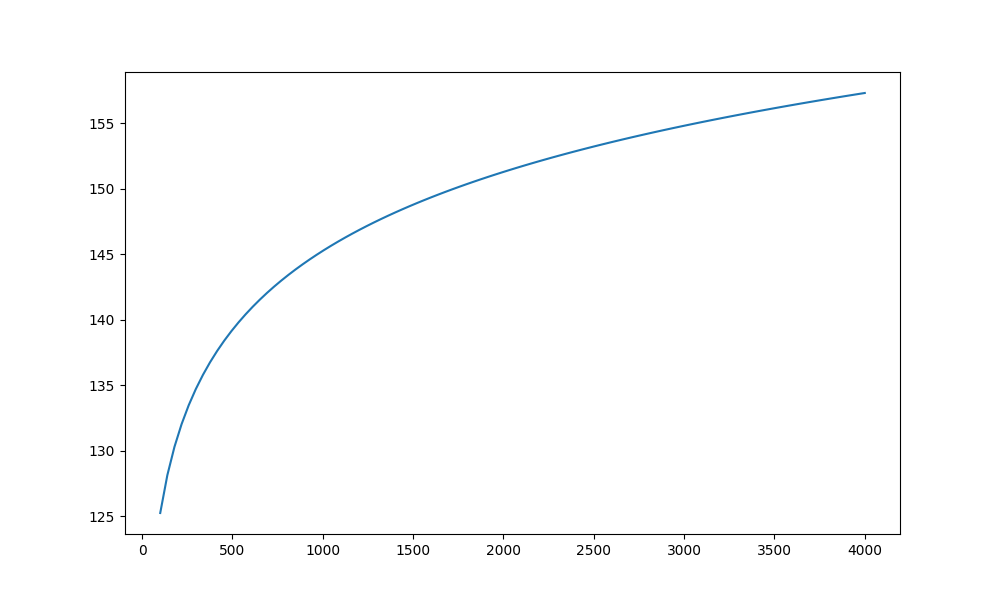

In [31]:
fig = plt.figure(figsize=(10, 6))
ax_fspl = plt.subplot(1, 1, 1)
ax_fspl.plot(distance / 1e3, fspl, label='FSPL (dB)')

plt.show()

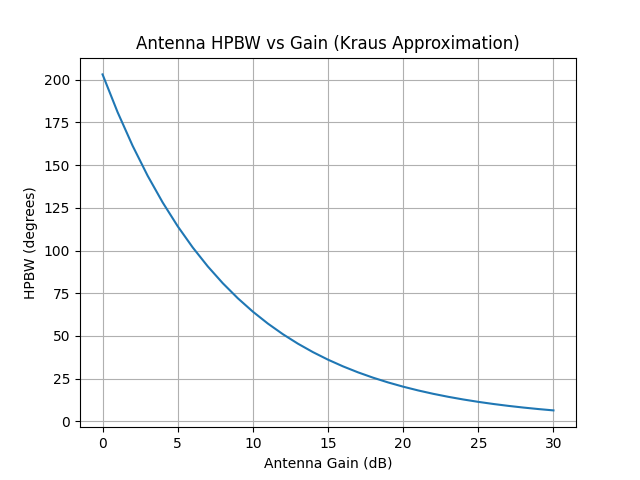

In [32]:
def antenna_gain_kraus_db(hpbw_deg):
  gain = 360**2 / np.pi / hpbw_deg**2
  gain_db = 10 * np.log10(gain)
  return gain_db

def antenna_hpbw_kraus_db(gain_db):
  gain = 10**(gain_db / 10)
  hpbw_deg = np.sqrt(360**2 / np.pi / gain)
  return hpbw_deg

antenna_gain_db = np.arange(0, 30+1, 1)

fig = plt.figure()
ax = plt.subplot(111)
ax.plot(antenna_gain_db, antenna_hpbw_kraus_db(antenna_gain_db))
ax.set_xlabel('Antenna Gain (dB)')
ax.set_ylabel('HPBW (degrees)')
ax.set_title('Antenna HPBW vs Gain (Kraus Approximation)')
ax.grid()
plt.show()


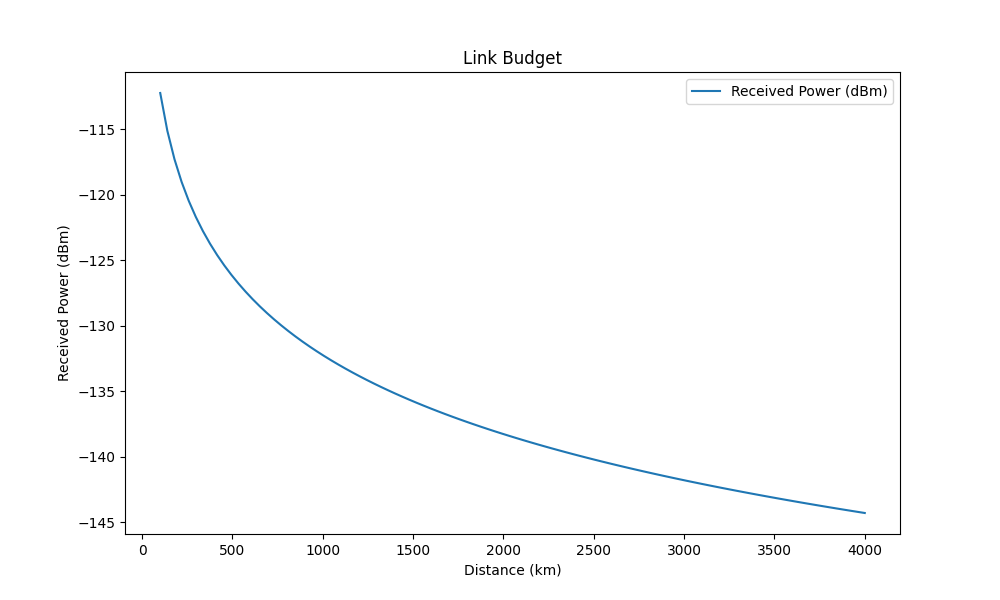

In [33]:
losses = [
  ("tx power [dBm]", 20),
  ("tx antenna gain [dBi]", 0),
  ("free space path loss [dB]", -fspl),
  ("rx antenna gain [dBi]", 0),
  ("polarization mismatch [dB]", -3),
  ("implementation loss [dB]", -4),
  ("pointing loss [dB]", 0),
]

rx_power_dbm = sum(loss[1] for loss in losses)
plt.figure(figsize=(10, 6))
plt.plot(distance / 1e3, rx_power_dbm, label='Received Power (dBm)')
plt.xlabel('Distance (km)')
plt.ylabel('Received Power (dBm)')
plt.title('Link Budget')
plt.legend()
plt.show()

In [38]:
lora_params = {
  "bw": [
    62.5*1e3,
    125*1e3,
    250*1e3,
    500*1e3,
  ],
  "cr": [1, 2, 3, 4],
  "sf": [7, 8, 9, 10, 11, 12]
}
lora_snr_limits_db = {
  "sf7": {"snr_limit": -7.5},
  "sf8": {"snr_limit": -10.0},
  "sf9": {"snr_limit": -12.5},
  "sf10": {"snr_limit": -15.0},
  "sf11": {"snr_limit": -17.5},
  "sf12": {"snr_limit": -20.0},
}

In [39]:
def processing_gain_db(sf, bw, cr = 1):
  rs = bw / (2 ** sf)
  rc = rs * 2 ** sf
  rb = sf * (4 / (4 + cr)) / (2 ** sf / bw)
  return 10 * np.log10(rc / rb)

In [40]:
noise_temp_c = np.linspace(0, 100, 100)
noise_temp_k = noise_temp_c + 273.15
bandwidth_hz = np.array(lora_params["bw"]) 
noise_power_dbm = 10 * np.log10(noise_temp_k[:, np.newaxis] * bandwidth_hz[np.newaxis, :] * k)
noise_power_dbm += 30 # Convert from dBW to dBm
noise_power_dbm_25C = noise_power_dbm[25, :]
dnoise_temp_dbm = np.diff(noise_power_dbm, axis=0)
print(f"Noise Power sensitivity (dB per °C): {dnoise_temp_dbm.mean():.2f} dB/°C")
print(f"Noise Power at 25°C (dBm): {noise_power_dbm_25C}")

Noise Power sensitivity (dB per °C): 0.01 dB/°C
Noise Power at 25°C (dBm): [-125.89234206 -122.8820421  -119.87174215 -116.86144219]


SNR bandwidth for SF7: [1124.24242424  809.09090909  572.72727273  415.15151515] km
SNR bandwidth for SF8: [1518.18181818 1084.84848485  769.6969697   533.33333333] km
SNR bandwidth for SF9: [2030.3030303  1439.39393939 1006.06060606  730.3030303 ] km
SNR bandwidth for SF10: [2700.         1912.12121212 1360.60606061  966.66666667] km
SNR bandwidth for SF11: [3606.06060606 2542.42424242 1793.93939394 1281.81818182] km
SNR bandwidth for SF12: [4000.         3409.09090909 2424.24242424 1715.15151515] km


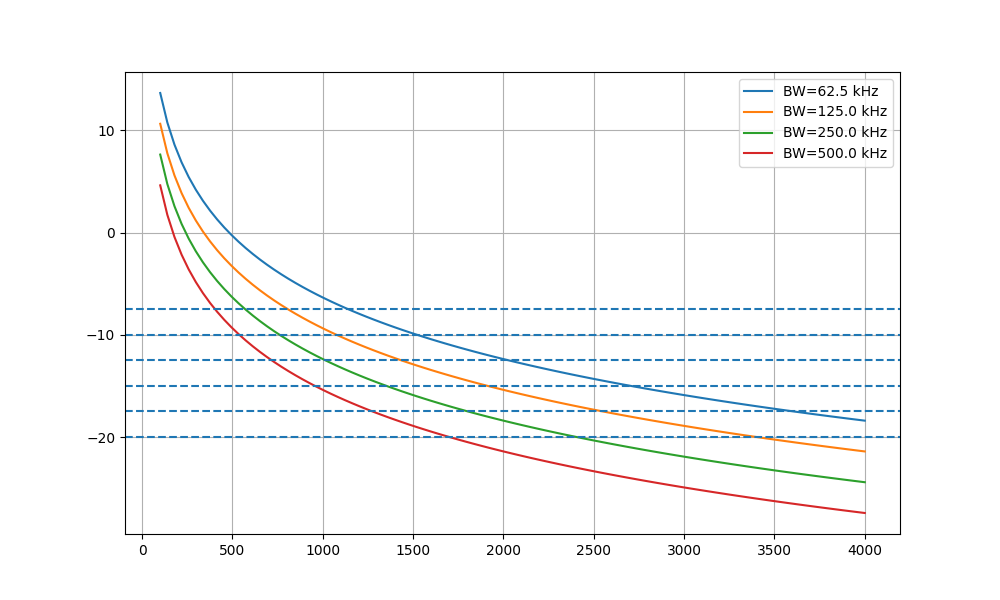

In [41]:
snr_db = rx_power_dbm - noise_power_dbm_25C[:, np.newaxis]

fig = plt.figure(figsize=(10, 6))
ax_snr = plt.subplot(1, 1, 1)
ax_snr.plot(distance / 1e3, snr_db.T, label='SNR (dB)')
ax_snr.legend([f"BW={bw/1e3:.1f} kHz" for bw in lora_params["bw"]])
for sf in lora_params["sf"]:
  snr_limit_db = lora_snr_limits_db[f"sf{sf}"]["snr_limit"]
  ax_snr.axhline(snr_limit_db, linestyle='--', label=f'SF{sf} SNR Limit ({snr_limit_db} dB)')
  snr_bw = np.argmin(np.abs(snr_db - snr_limit_db), axis=1)
  print(f"SNR bandwidth for SF{sf}: {distance[snr_bw]/1e3} km")
ax_snr.grid()
plt.show()